__Task 1__

1) 5 examples for using ML in real life:
- Спам-фильтр в почте
- Рекомендательная система
- Распознавание лиц на фото
- Предсказание цены на жилье
- Диагностика заболеваний по анализам

В чем преимущество использования МО в каждом примере:
    Автоматизация (вместо ручной обработки).
    Адаптация под пользователя (рекомендации).
    Скорость обработки больших объемов данных.
    Предиктивность — предсказания на основе обучающего опыта.
    Точность — повышение точности в задачах, где есть закономерности, трудно формализуемые вручную.

2) Классификация для примеров выше:
- Supervised - Classification 
- Supervised - Classification/Unsupervised - Clustering
- Supervised - Classification
- Supervised - Regression
- Supervised - Classification

3) Мультилейбл означает, что один объект может принадлежать сразу нескольким классам одновременно. Это отличается от обычной классификации, где объекту присваивается только одна метка.

4) Нет, это задача регрессии, потому что мы предсказываем непрерывную величину.
Можно ли свести задачу регрессии к классификации? Да, но с потерей точности. Например, можно разбить цены на интервалы: дешево/средне/дорого.

__Task 2__

In [30]:
import pandas as pd
df = pd.read_json("train.json")

print(df.shape)

(49352, 15)


In [31]:
print(df.columns)

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')


target - Price

In [32]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [34]:
df.isna().sum()

bathrooms          0
bedrooms           0
building_id        0
created            0
description        0
display_address    0
features           0
latitude           0
listing_id         0
longitude          0
manager_id         0
photos             0
price              0
street_address     0
interest_level     0
dtype: int64

In [35]:
df = df[['bathrooms', 'bedrooms', 'interest_level', 'price']]
df.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


__Task 3__

In [36]:
df.describe()

,bathrooms,bedrooms,price
count,49352.00000,49352.000000,4.935200e+04
mean,1.21218,1.541640,3.830174e+03
std,0.50142,1.115018,2.206687e+04
min,0.00000,0.000000,4.300000e+01
25%,1.00000,1.000000,2.500000e+03
50%,1.00000,1.000000,3.150000e+03
75%,1.00000,2.000000,4.100000e+03
max,10.00000,8.000000,4.490000e+06


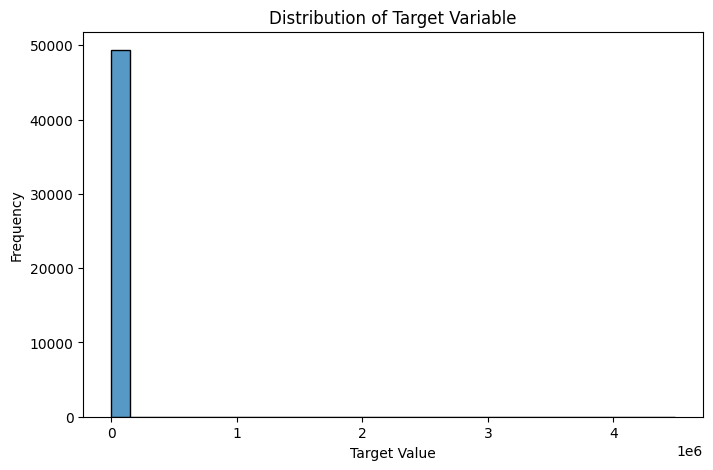

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=30)
plt.title("Distribution of Target Variable")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.show()

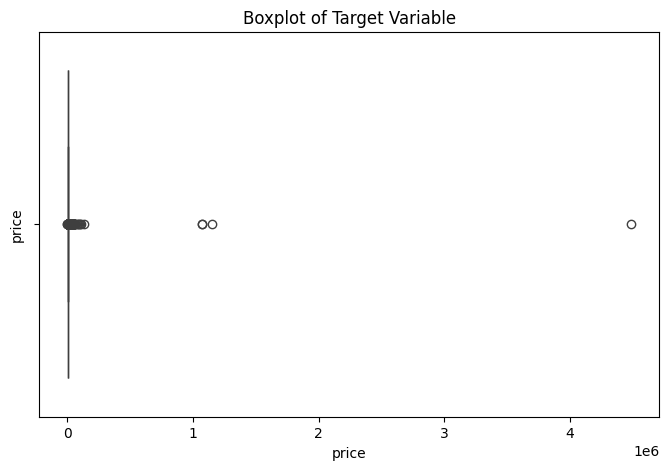

In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['price'])
plt.title("Boxplot of Target Variable")
plt.ylabel('price')
plt.show()

In [39]:
upper_threshold = df["price"].quantile(0.99)
lower_threshold = df["price"].quantile(0.01)
df_filtered = df[(df["price"] <= upper_threshold) & (df["price"] >= lower_threshold)]


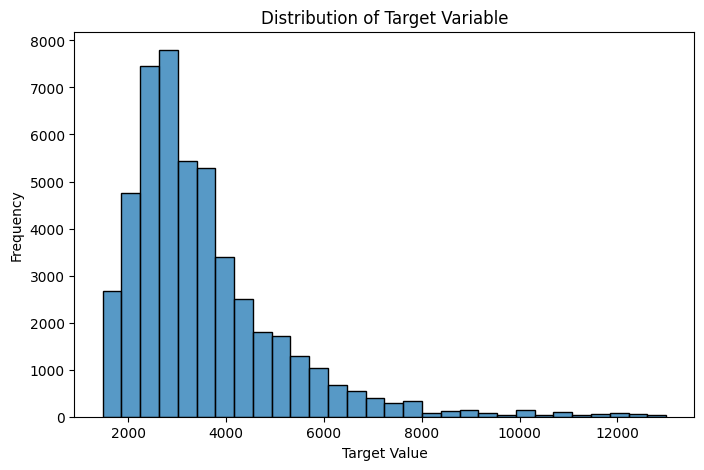

In [40]:
plt.figure(figsize=(8, 5))
sns.histplot(df_filtered['price'], bins=30)
plt.title("Distribution of Target Variable")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.show()

Column 'interest_level' is an Object type.

In [41]:
df_filtered['interest_level'].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

In [42]:
from sklearn.preprocessing import LabelEncoder

labels = df_filtered["interest_level"]
encoder = LabelEncoder()
df_filtered["interest_level_encoded"] = encoder.fit_transform(labels)

label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Label mapping:", label_mapping)

Label mapping: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}


/tmp/ipykernel_2686/3360614419.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["interest_level_encoded"] = encoder.fit_transform(labels)


In [43]:
df_filtered.sample(5)

,bathrooms,bedrooms,interest_level,price,interest_level_encoded
20503,1.0,1,low,3350,1
81349,2.0,4,medium,5960,2
4592,1.0,1,low,2350,1
26515,1.0,2,low,3500,1
92326,1.0,3,medium,3100,2


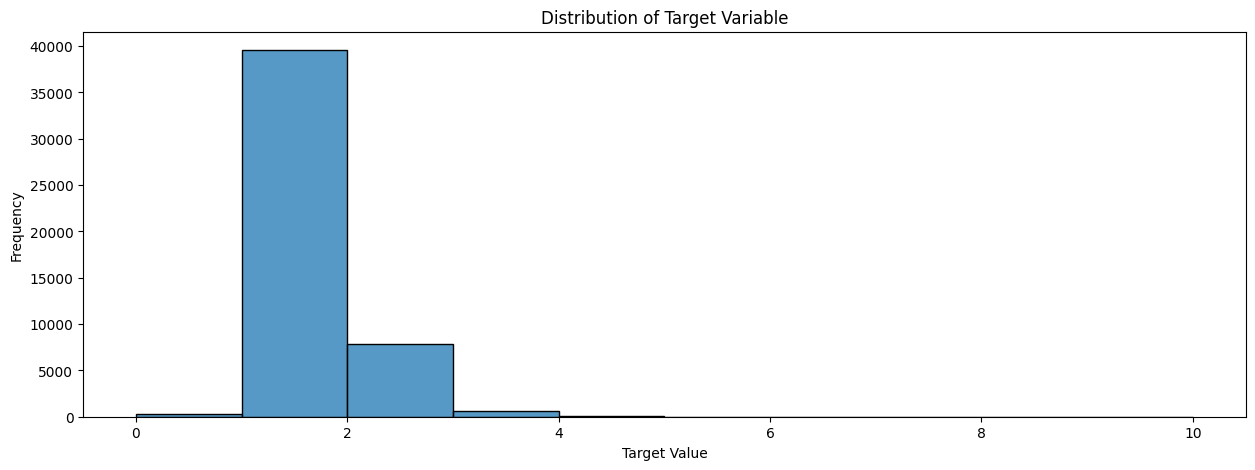

In [44]:
plt.figure(figsize=(15, 5))
sns.histplot(df_filtered['bathrooms'], bins=10)
plt.title("Distribution of Target Variable")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.show()

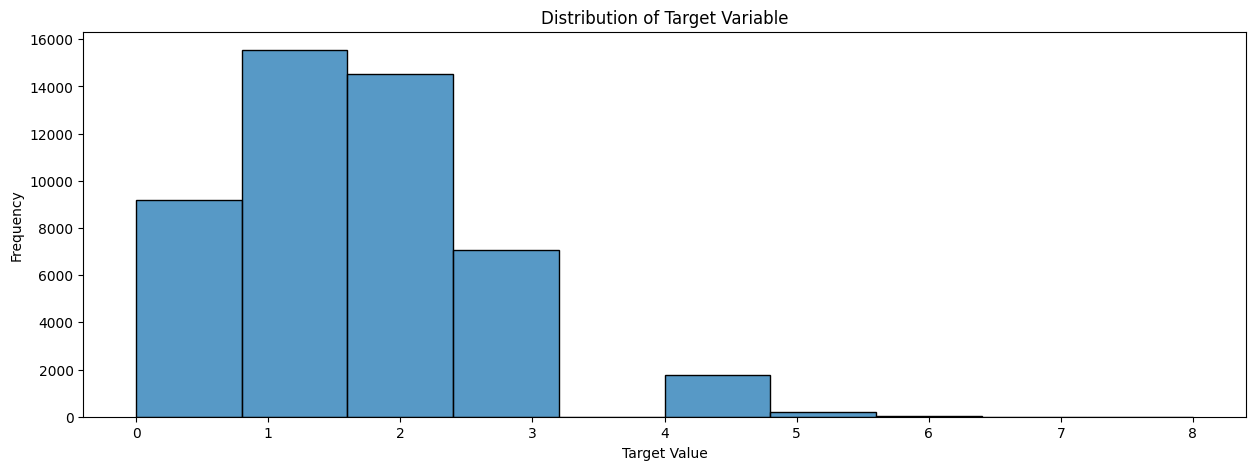

In [45]:
plt.figure(figsize=(15, 5))
sns.histplot(df_filtered['bedrooms'], bins=10)
plt.title("Distribution of Target Variable")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.show()

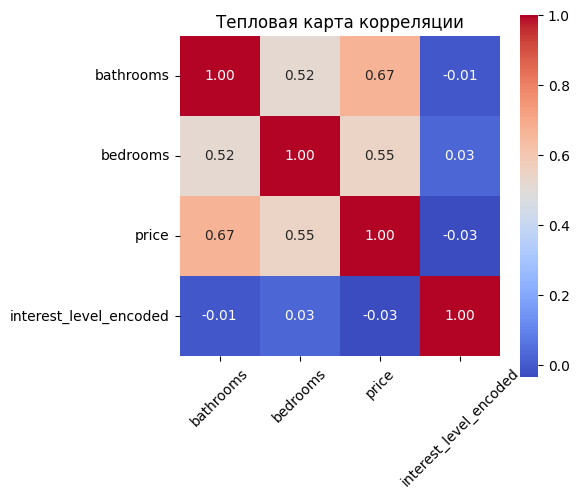

In [46]:
number_columns = df_filtered.select_dtypes(include='number').columns

corr_matrix = df_filtered[number_columns].corr()
plt.figure(figsize=(6, 6))
sns.heatmap(corr_matrix, 
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            square=True,
            cbar_kws={"shrink": 0.75})
plt.title("Тепловая карта корреляции")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

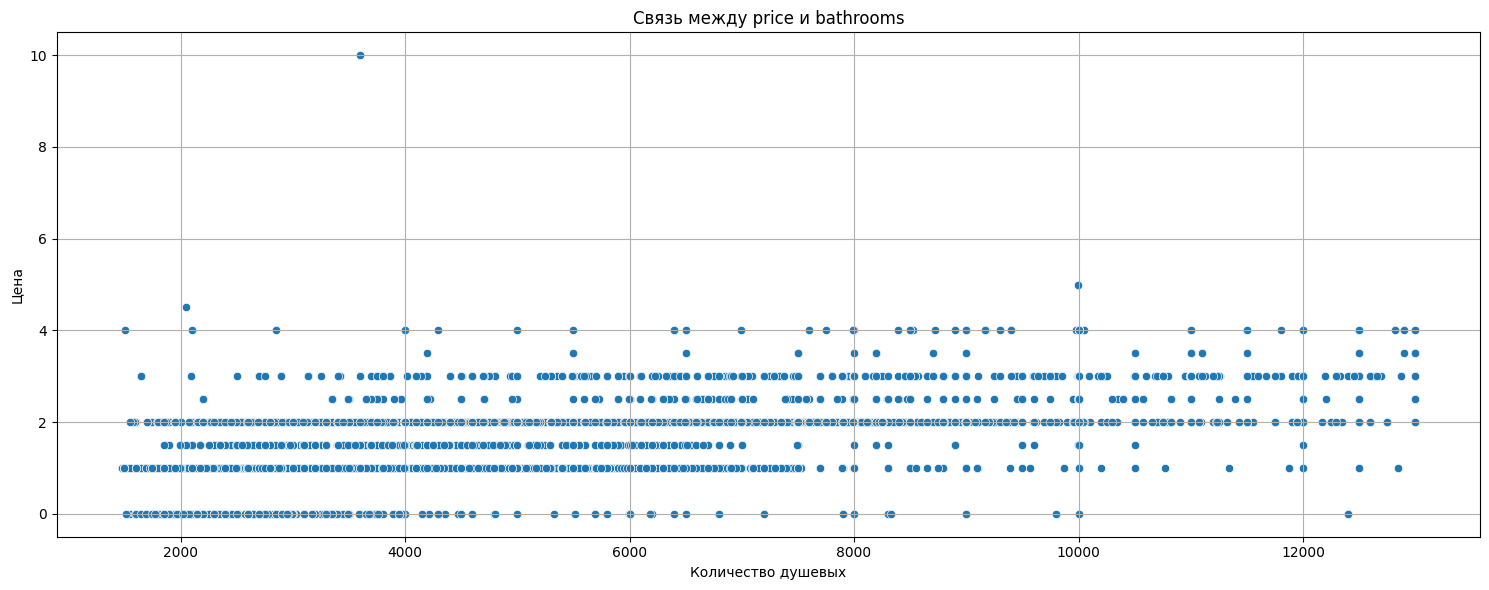

In [47]:
plt.figure(figsize=(15, 6))
sns.scatterplot(data=df_filtered, x="price", y="bathrooms")
plt.title("Связь между price и bathrooms")
plt.xlabel("Количество душевых")
plt.ylabel("Цена")
plt.grid(True)
plt.tight_layout()
plt.show()

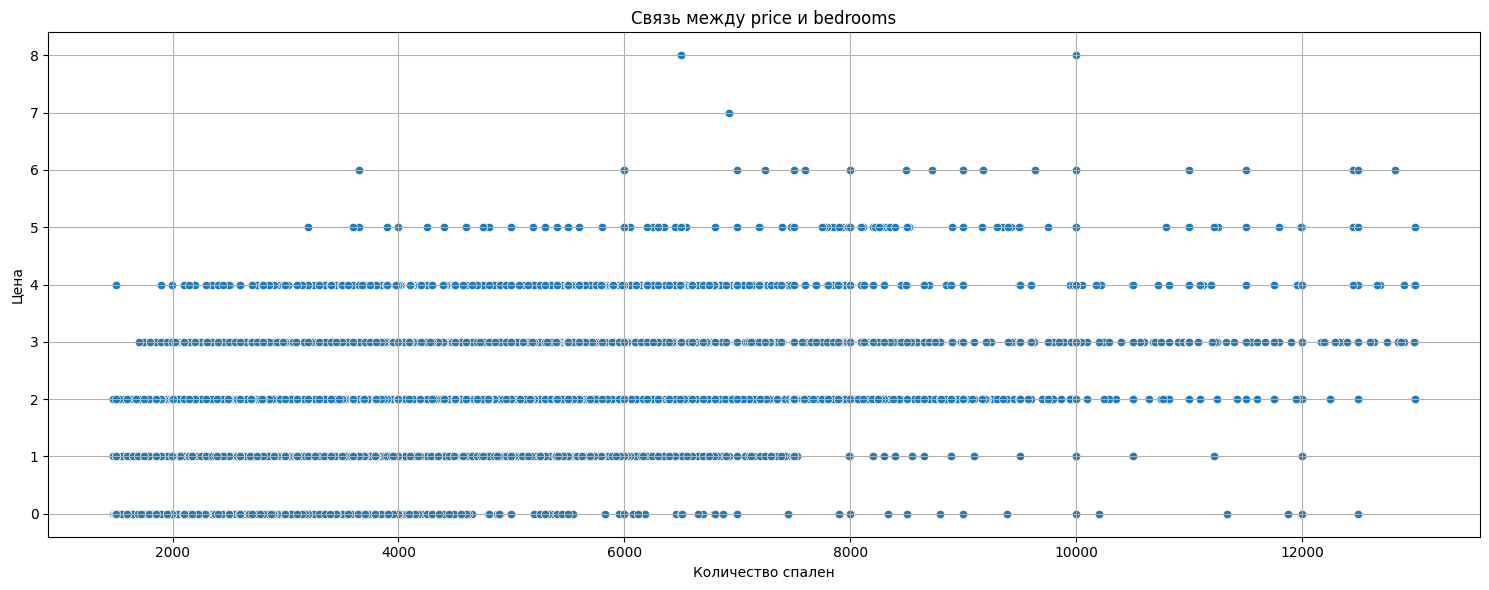

In [48]:
plt.figure(figsize=(15, 6))
sns.scatterplot(data=df_filtered, x="price", y="bedrooms")
plt.title("Связь между price и bedrooms")
plt.xlabel("Количество спален")
plt.ylabel("Цена")
plt.grid(True)
plt.tight_layout()
plt.show()

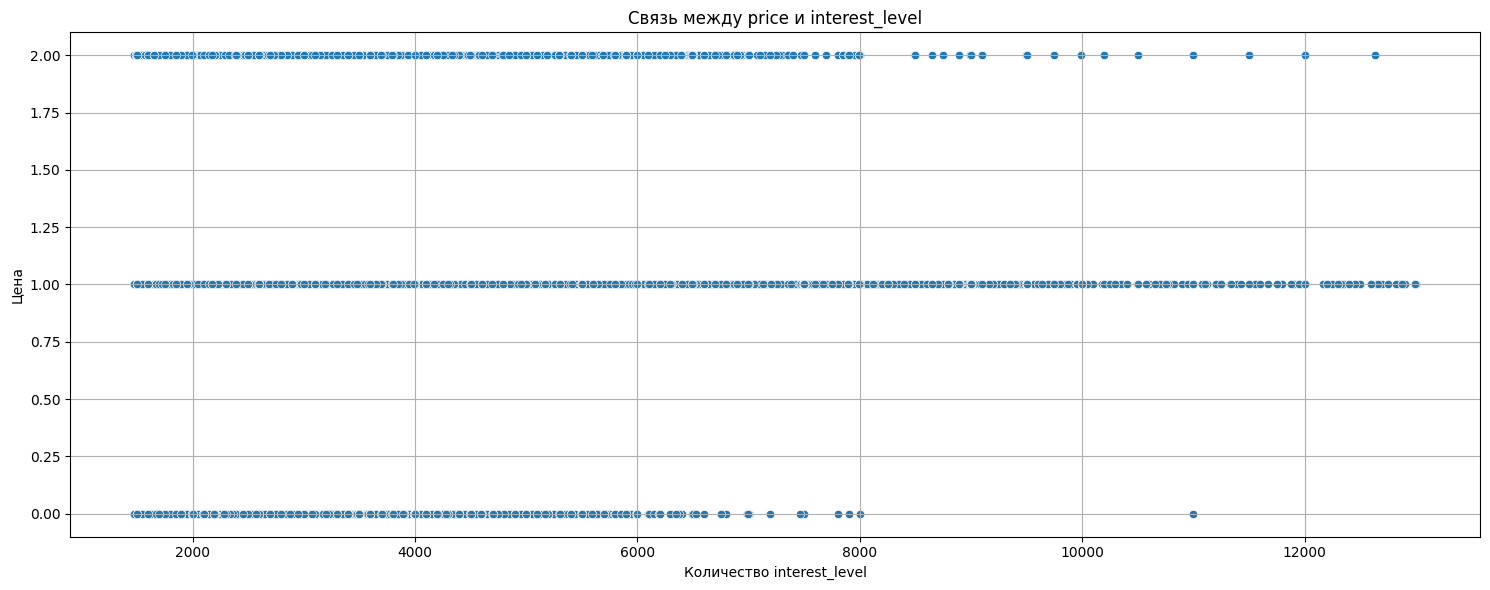

In [49]:
plt.figure(figsize=(15, 6))
sns.scatterplot(data=df_filtered, x="price", y="interest_level_encoded")
plt.title("Связь между price и interest_level")
plt.xlabel("Количество interest_level")
plt.ylabel("Цена")
plt.grid(True)
plt.tight_layout()
plt.show()

__Task 4__

In [50]:
df_filtered = df_filtered.copy()

df_filtered['bathrooms_squared'] = df_filtered['bathrooms'] * 2
df_filtered['bedrooms_squared'] = df_filtered['bedrooms'] * 2
df_filtered['interest_level_squared'] = df_filtered['interest_level_encoded'] * 2

In [51]:
number_columns = df_filtered.select_dtypes(include='number').columns
corr_matrix = df_filtered[number_columns].corr()
corr_matrix

,bathrooms,bedrooms,price,interest_level_encoded,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000000,0.517574,0.671943,-0.006578,1.000000,0.517574,-0.006578
bedrooms,0.517574,1.000000,0.545948,0.028754,0.517574,1.000000,0.028754
price,0.671943,0.545948,1.000000,-0.033239,0.671943,0.545948,-0.033239
interest_level_encoded,-0.006578,0.028754,-0.033239,1.000000,-0.006578,0.028754,1.000000
bathrooms_squared,1.000000,0.517574,0.671943,-0.006578,1.000000,0.517574,-0.006578
bedrooms_squared,0.517574,1.000000,0.545948,0.028754,0.517574,1.000000,0.028754
interest_level_squared,-0.006578,0.028754,-0.033239,1.000000,-0.006578,0.028754,1.000000


In [52]:
new_df = df_filtered[['bathrooms_squared', 'bedrooms_squared', 'price']]
new_df.head()

X = new_df.drop('price', axis=1)
y = new_df['price']

In [ ]:
from sklearn.model_selection import train_test_split

test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=21)

print(f'X_train: {X_train.shape}')
print(f'y_train:  {y_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_test:  {y_test.shape}')

X_train: (38703, 2)
y_train:  (38703,)
X_test:  (9676, 2)
y_test:  (9676,)


In [56]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(10)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

__Task 5__

In [73]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [86]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

In [87]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

train_pred_lr = lin_reg.predict(X_train)
test_pred_lr = lin_reg.predict(X_test)

mae_train_lr = mean_absolute_error(y_train, train_pred_lr)
mae_test_lr = mean_absolute_error(y_test, test_pred_lr)
rmse_train_lr = np.sqrt(mean_squared_error(y_train, train_pred_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, test_pred_lr))

result_MAE.loc[len(result_MAE)] = ['linreg', mae_train_lr, mae_test_lr]
result_RMSE.loc[len(result_RMSE)] = ['linreg', rmse_train_lr, rmse_test_lr]

In [88]:
tree_reg = DecisionTreeRegressor(random_state=21)
tree_reg.fit(X_train, y_train)

train_pred_tree = tree_reg.predict(X_train)
test_pred_tree = tree_reg.predict(X_test)

mae_train_tree = mean_absolute_error(y_train, train_pred_tree)
mae_test_tree = mean_absolute_error(y_test, test_pred_tree)
rmse_train_tree = np.sqrt(mean_squared_error(y_train, train_pred_tree))
rmse_test_tree = np.sqrt(mean_squared_error(y_test, test_pred_tree))

result_MAE.loc[len(result_MAE)] = ['tree', mae_train_tree, mae_test_tree]
result_RMSE.loc[len(result_RMSE)] = ['tree', rmse_train_tree, rmse_test_tree]

In [89]:
mean_train = np.mean(y_train)
mean_test = np.mean(y_test)

train_pred_mean = [mean_train] * len(y_train)
test_pred_mean = [mean_train] * len(y_test)

mae_train_mean = mean_absolute_error(y_train, train_pred_mean)
mae_test_mean = mean_absolute_error(y_test, test_pred_mean)
rmse_train_mean = np.sqrt(mean_squared_error(y_train, train_pred_mean))
rmse_test_mean = np.sqrt(mean_squared_error(y_test, test_pred_mean))

result_MAE.loc[len(result_MAE)] = ['mean', mae_train_mean, mae_test_mean]
result_RMSE.loc[len(result_RMSE)] = ['mean', rmse_train_mean, rmse_test_mean]

In [90]:
median_train = np.median(y_train)

train_pred_median = [median_train] * len(y_train)
test_pred_median = [median_train] * len(y_test)

mae_train_median = mean_absolute_error(y_train, train_pred_median)
mae_test_median = mean_absolute_error(y_test, test_pred_median)
rmse_train_median = np.sqrt(mean_squared_error(y_train, train_pred_median))
rmse_test_median = np.sqrt(mean_squared_error(y_test, test_pred_median))

result_MAE.loc[len(result_MAE)] = ['median', mae_train_median, mae_test_median]
result_RMSE.loc[len(result_RMSE)] = ['median', rmse_train_median, rmse_test_median]

In [91]:
result_MAE

,model,train,test
0,linreg,786.185024,779.802837
1,tree,758.506903,750.518322
2,mean,1140.971980,1133.337125
3,median,1087.151797,1082.445432


In [92]:
result_RMSE

,model,train,test
0,linreg,1124.386470,1121.947009
1,tree,1081.885757,1064.830440
2,mean,1600.980072,1584.244605
3,median,1647.698503,1630.315025
